In [2]:
from google.colab import files
import pandas as pd

# Ask user to upload the dataset (e.g., ex2data1.txt)
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

# Robust loader: try comma, then fallback to mixed commas/whitespace
try:
    df = pd.read_csv(filename, header=None, names=['Exam1', 'Exam2', 'Admitted'])
except Exception:
    df = pd.read_csv(filename, header=None, names=['Exam1', 'Exam2', 'Admitted'],
                     sep=r'[,\s]+', engine='python')

# Ensure numeric and drop any malformed rows
df = df.apply(pd.to_numeric, errors='coerce').dropna()

print("Shape:", df.shape)
df.head()


Saving ex2data1.txt to ex2data1.txt
Uploaded file: ex2data1.txt
Shape: (100, 3)


,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [3]:
# Basic info and class balance
df.info()
print(df.describe())

print("\nClass balance:")
print(df['Admitted'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
            Exam1       Exam2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000

Class balance:
Admitted
1    60
0    40
Name: count, dtype: int64


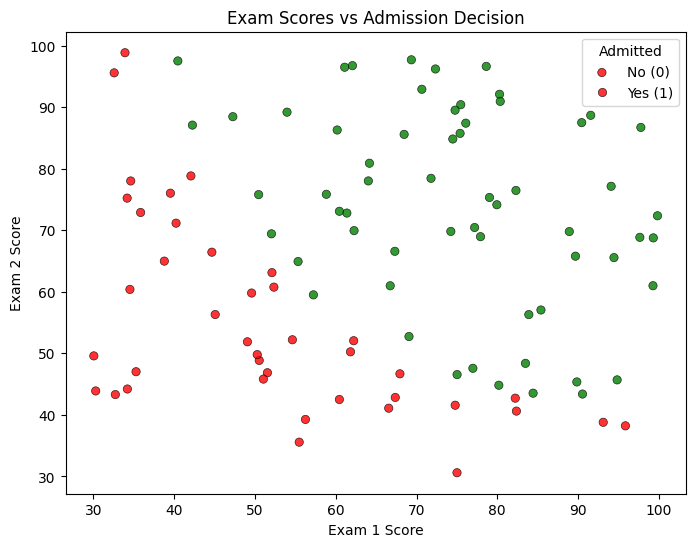

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Exam1', y='Exam2',
    hue='Admitted', palette={1: 'green', 0: 'red'},
    alpha=0.8, edgecolor='k'
)
plt.title('Exam Scores vs Admission Decision')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', labels=['No (0)', 'Yes (1)'])
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['Exam1', 'Exam2']]
y = df['Admitted']

# Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (70, 2) Test size: (30, 2)


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully.")


✅ Model trained successfully.


Accuracy: 0.933


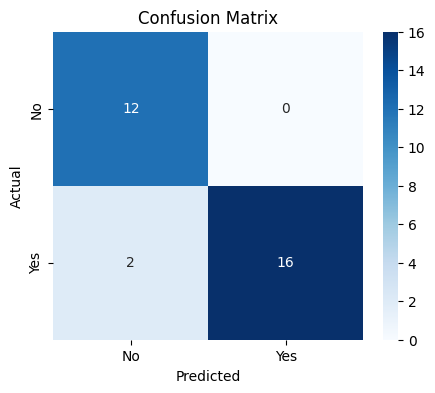


Classification Report:
              precision    recall  f1-score   support

          No       0.86      1.00      0.92        12
         Yes       1.00      0.89      0.94        18

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30



In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


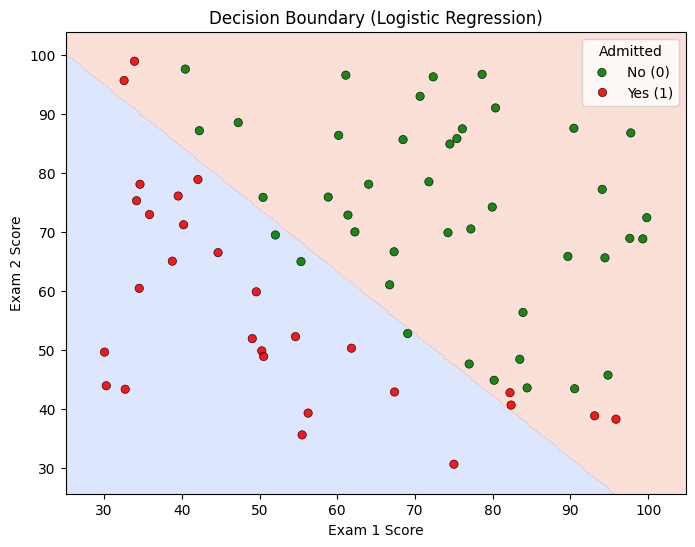

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a mesh in ORIGINAL feature space
x_min, x_max = X['Exam1'].min() - 5, X['Exam1'].max() + 5
y_min, y_max = X['Exam2'].min() - 5, X['Exam2'].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Transform the mesh with the SAME scaler, then predict
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
Z = model.predict(grid_scaled).reshape(xx.shape)

# Plot boundary + training points
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=[-0.1,0.5,1.1], alpha=0.3, cmap='coolwarm')
sns.scatterplot(
    x=X_train['Exam1'], y=X_train['Exam2'], hue=y_train,
    palette={1:'green', 0:'red'}, edgecolor='k', alpha=0.9
)
plt.title('Decision Boundary (Logistic Regression)')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', labels=['No (0)', 'Yes (1)'])
plt.show()


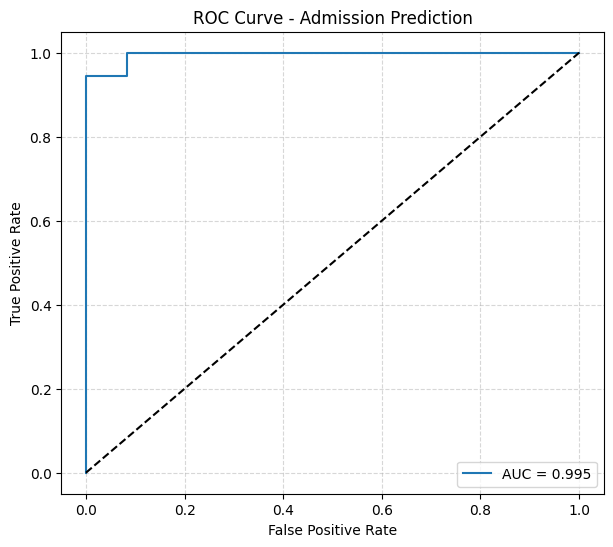

✅ ROC/AUC done. AUC = 0.995


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Admission Prediction')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"✅ ROC/AUC done. AUC = {auc:.3f}")
